<a href="https://colab.research.google.com/github/Jivang0/machine_learning_all/blob/main/JivanGaire_Project3_LinearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing


In [ ]:
california = fetch_california_housing()

In [ ]:
df =pd.DataFrame(california.data,columns = california.feature_names)

In [ ]:
df.head(10)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25


In [ ]:
df.shape

(20640, 8)

In [ ]:
df["MedHouseVal"] = california.target
df.MedHouseVal.head()

,MedHouseVal
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422


In [ ]:
df.MedHouseVal.head(20)

,MedHouseVal
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422
5,2.697
6,2.992
7,2.414
8,2.267
9,2.611


In [ ]:
df.describe()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [ ]:
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


In [ ]:
df.dtypes

,0
MedInc,float64
HouseAge,float64
AveRooms,float64
AveBedrms,float64
Population,float64
AveOccup,float64
Latitude,float64
Longitude,float64
MedHouseVal,float64


In [ ]:
 #Exploratory Data Visualization
import matplotlib.pyplot as plt



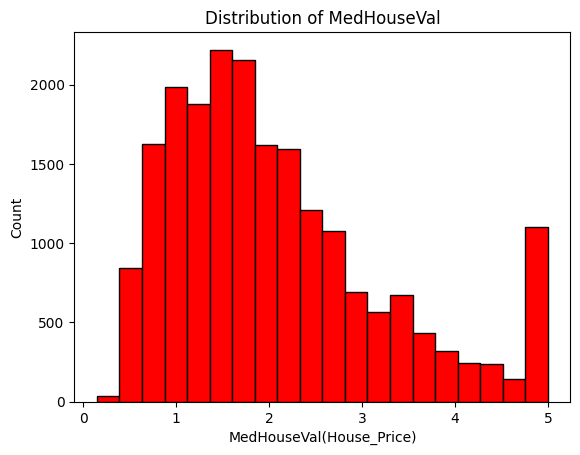

In [ ]:
plt.hist(df['MedHouseVal'], bins=20,color='red',edgecolor='black')
plt.xlabel('MedHouseVal(House_Price)')
plt.ylabel('Count')
plt.title('Distribution of MedHouseVal')
plt.show()


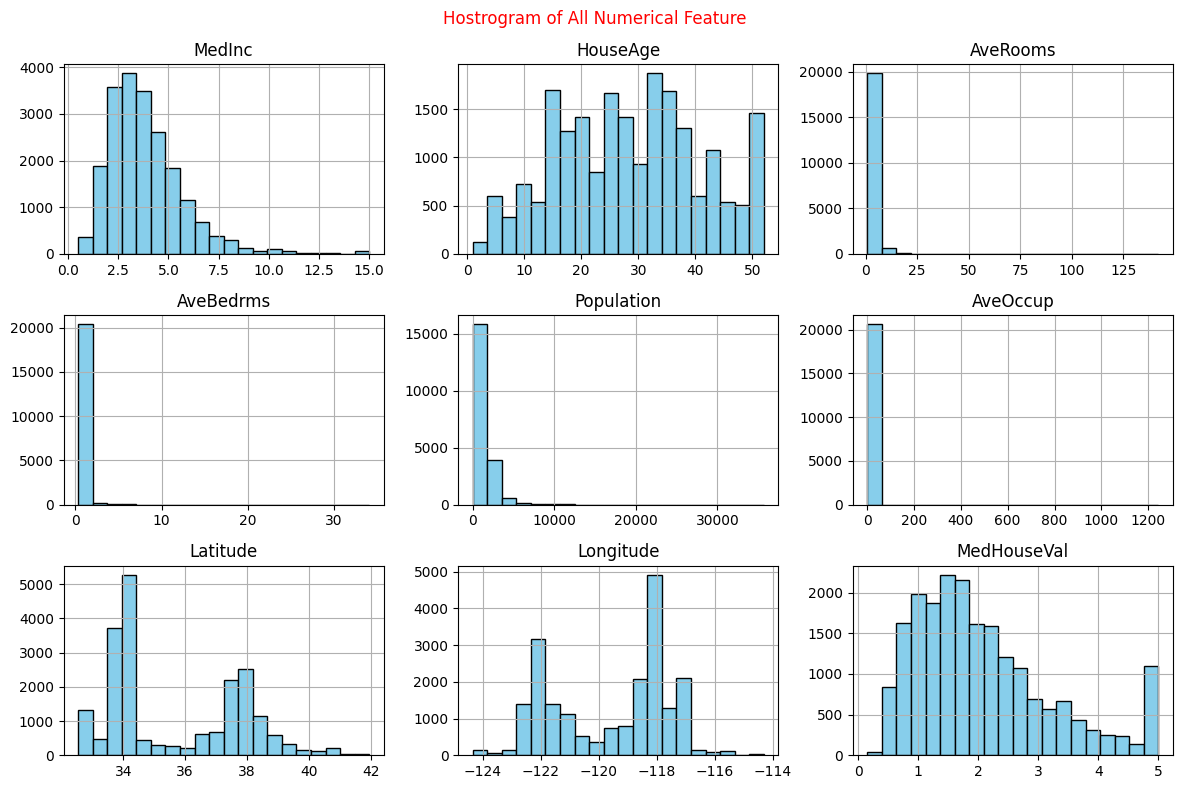

In [ ]:
df.hist(figsize=(12,8),bins=20,color='Skyblue',edgecolor='black')
plt.suptitle('Hostrogram of All Numerical Feature',fontsize=12,color='red')
plt.tight_layout()
plt.show()

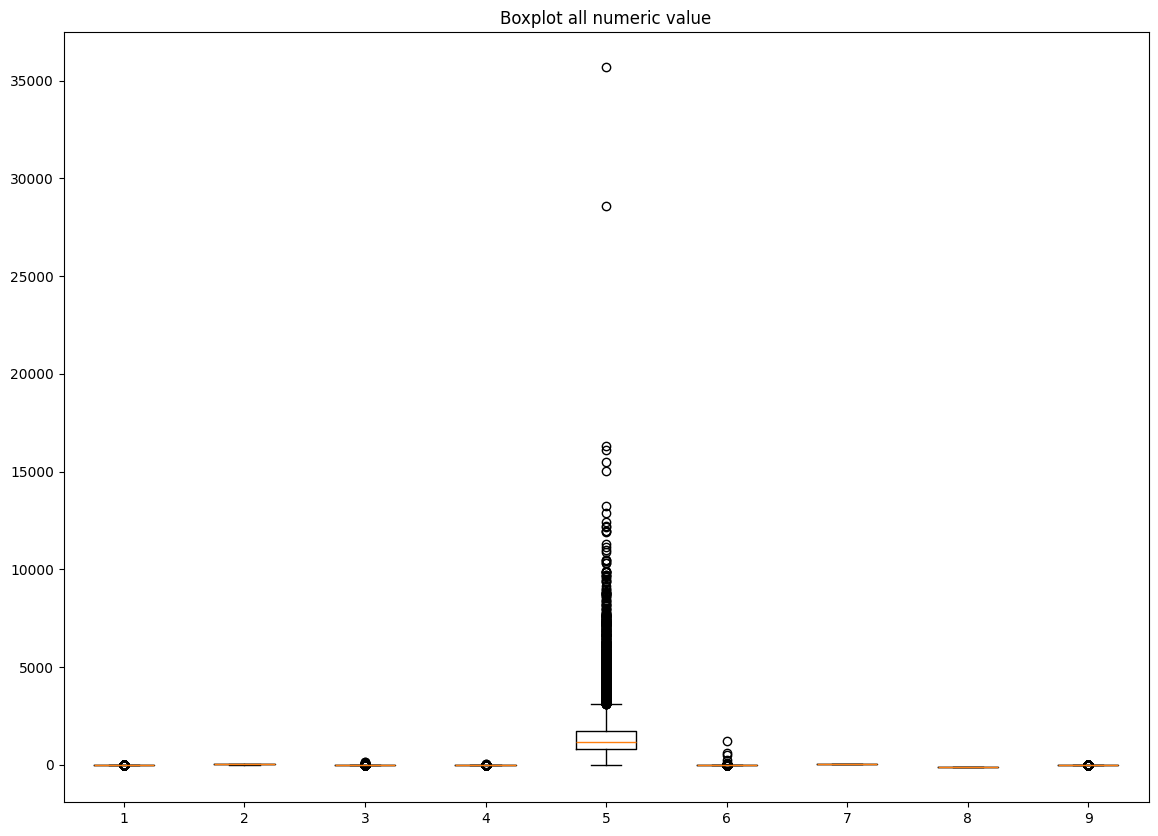

In [ ]:
plt.figure(figsize=(14,10))
plt.boxplot(df)
plt.title('Boxplot all numeric value')
plt.show()

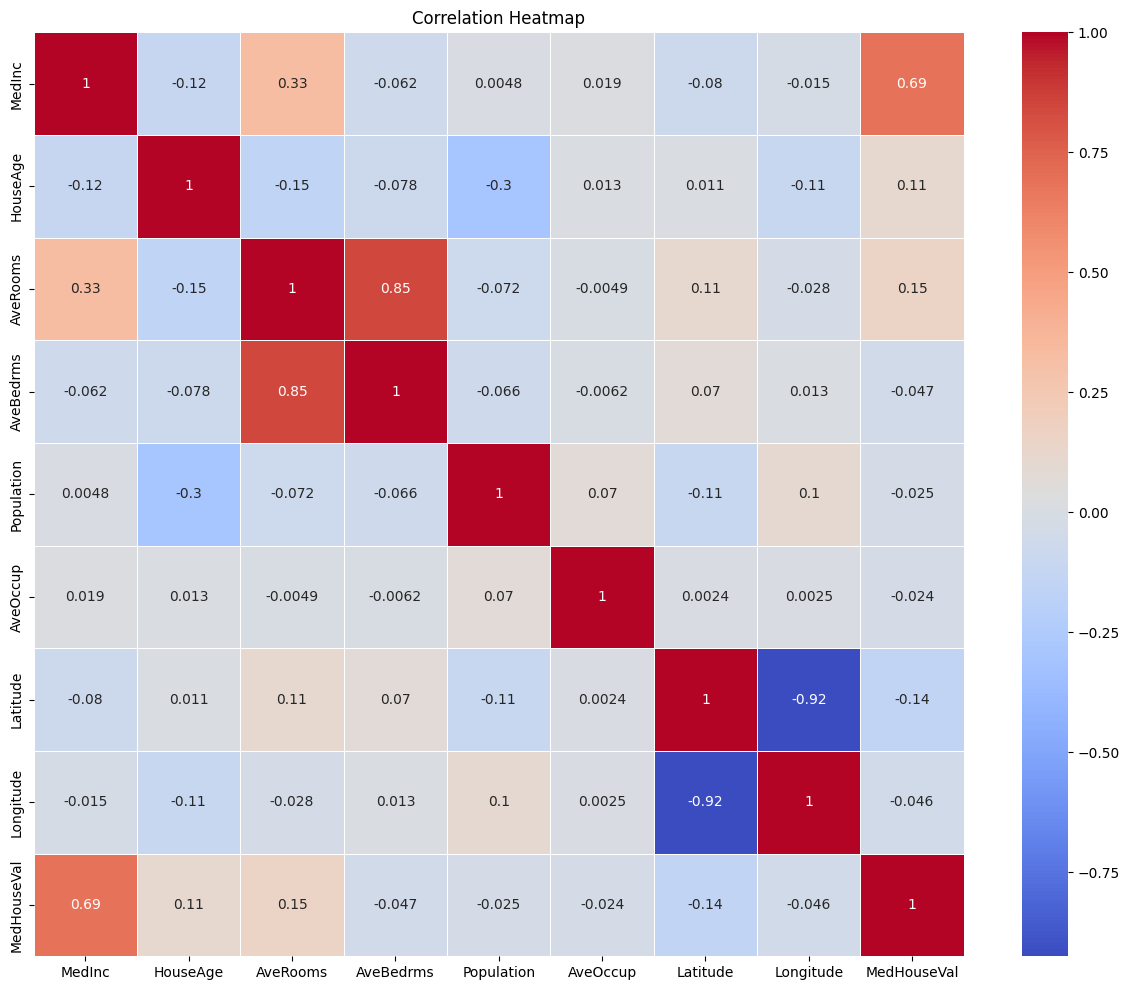

In [ ]:
import seaborn as sns
plt.figure(figsize=(15,12))
corr = df.corr()
sns.heatmap(corr,annot=True,cmap='coolwarm',linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()


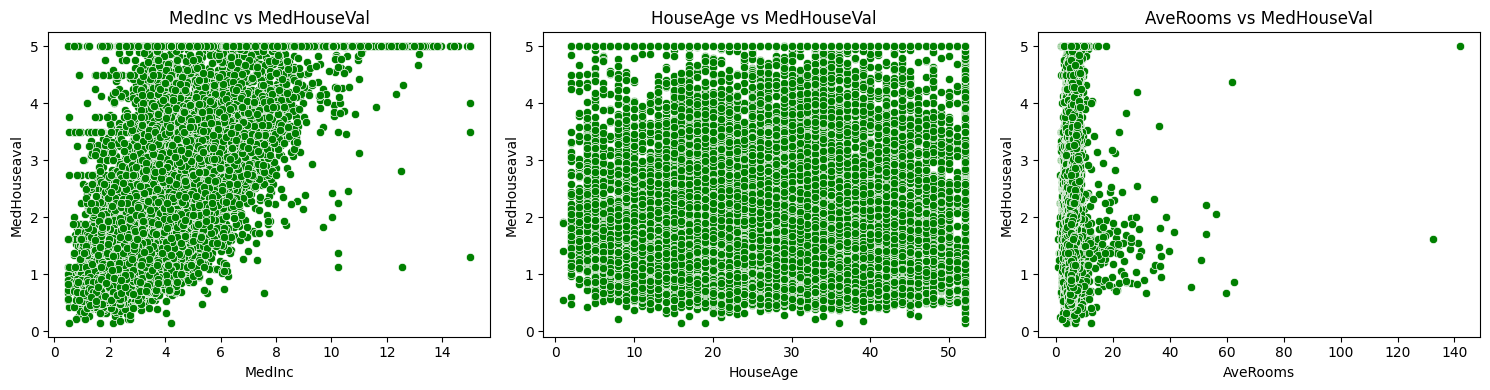

In [ ]:
#Scatter plots of the top 3 features most correlated with house prices
top_feature = ['MedInc','HouseAge','AveRooms']
plt.figure(figsize=(15,4))
for i,feature in enumerate(top_feature,1):
  plt.subplot(1,3,i)
  sns.scatterplot(x=df[feature],y=df['MedHouseVal'],color="green")
  plt.title(f'{feature} vs MedHouseVal')
  plt.xlabel(feature)
  plt.ylabel('MedHouseaval')
plt.tight_layout()
plt.show()

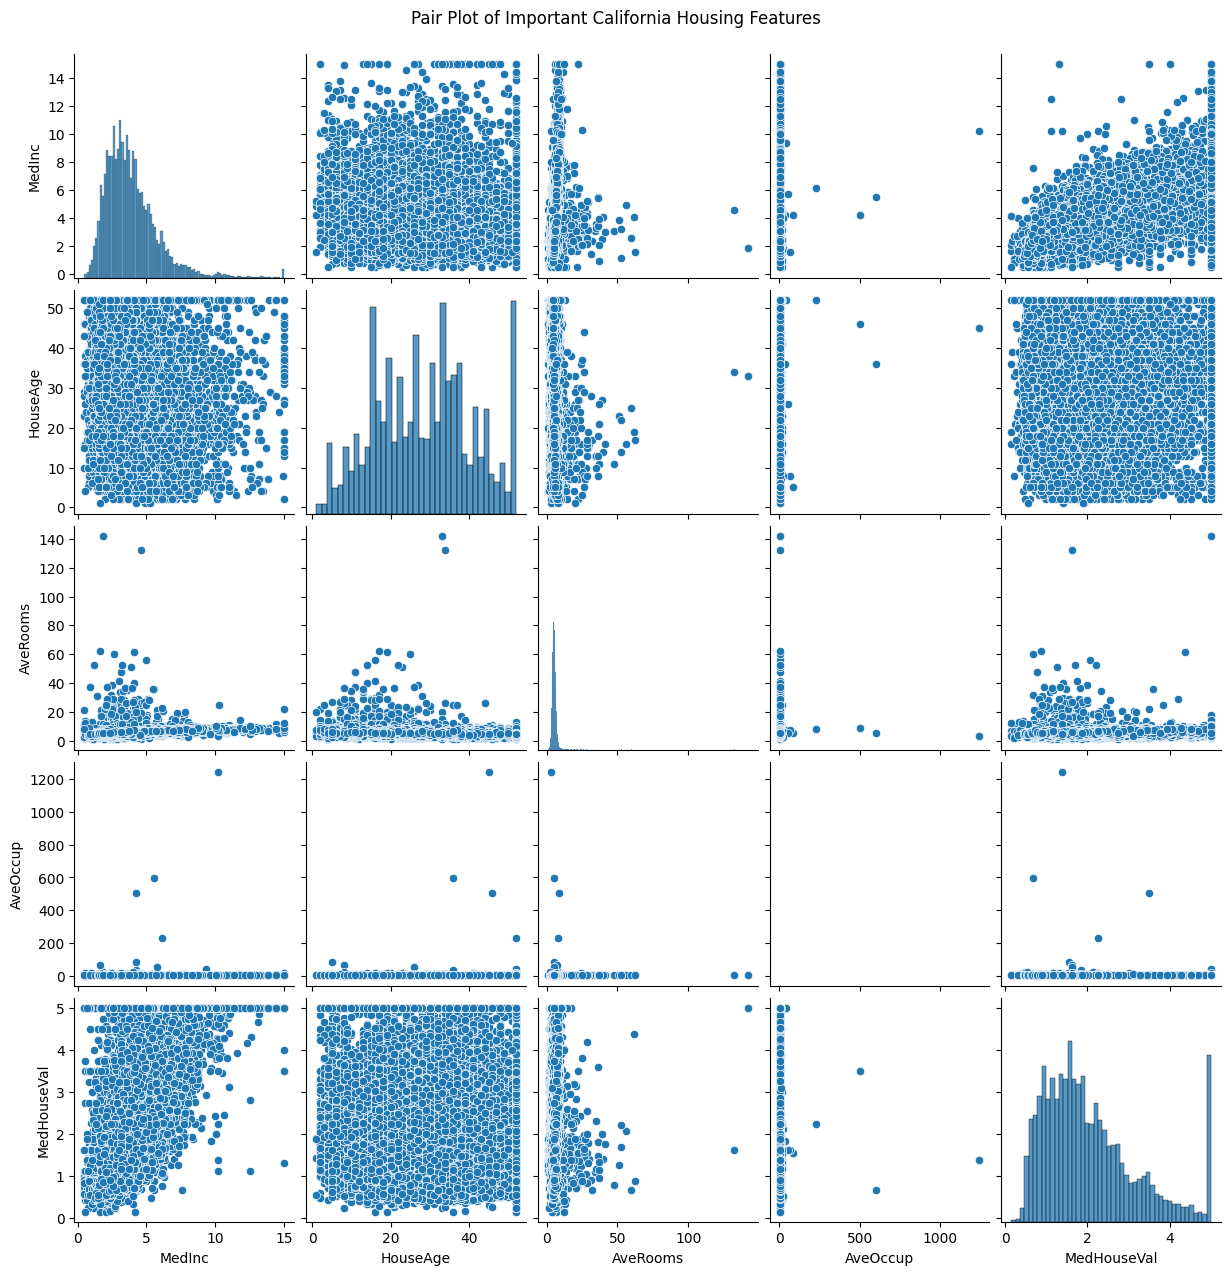

In [ ]:
# Pair plot for 4-5 most important features
sns.pairplot(df[['MedInc' ,'HouseAge','AveRooms', 'AveOccup', 'MedHouseVal']])
plt.suptitle("Pair Plot of Important California Housing Features", y=1.02)
plt.show()

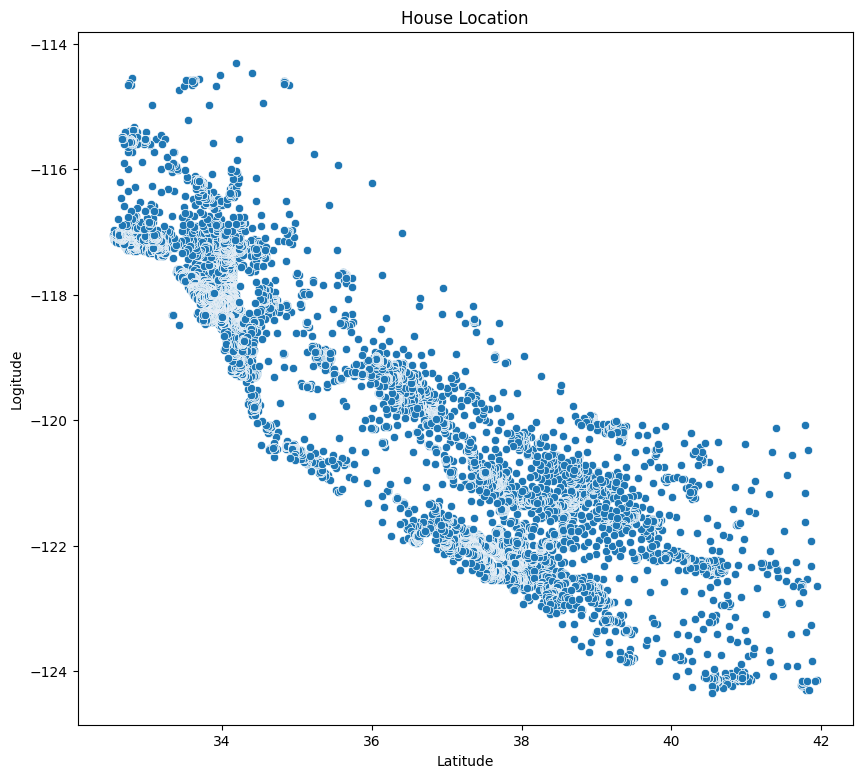

In [ ]:
# Scatter plot of house locations (latitude vs. longitude) colored by price
plt.figure(figsize=(10,9))
sns.scatterplot(x = df['Latitude'],y = df['Longitude'])
plt.title('House Location')
plt.xlabel('Latitude')
plt.ylabel('Logitude')
plt.show()


In [ ]:
#List the top 5 features with highest correlation to house prices
correlation = df.corr()['MedHouseVal'].sort_values(ascending=False).head(5)
correlation

,MedHouseVal
MedHouseVal,1.000000
MedInc,0.688075
AveRooms,0.151948
HouseAge,0.105623
AveOccup,-0.023737


In [ ]:
#  Report the percentage of outliers (values beyond 1.5 IQR) for each feature
outlier_percent = {}

for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Count how many values are outside the bounds
    outliers = df[(df[col] < lower) | (df[col] > upper)]

    # Calculate percentage
    outlier_percent[col] = (len(outliers) / len(df)) * 100

# Convert to DataFrame for readability
outlier_df = pd.DataFrame.from_dict(outlier_percent, orient='index', columns=['% of Outliers'])
outlier_df = outlier_df.sort_values(by='% of Outliers', ascending=False)

print(outlier_df)


             % of Outliers
AveBedrms         6.899225
Population        5.794574
MedHouseVal       5.188953
AveOccup          3.444767
MedInc            3.299419
AveRooms          2.475775
HouseAge          0.000000
Latitude          0.000000
Longitude         0.000000


In [ ]:
Q1 = df.quantile(0.25)
Q1

,0.25
MedInc,2.563400
HouseAge,18.000000
AveRooms,4.440716
AveBedrms,1.006079
Population,787.000000
AveOccup,2.429741
Latitude,33.930000
Longitude,-121.800000
MedHouseVal,1.196000


In [ ]:
#3.4.2 Feature Scaling
#1.Implement standardization (z-score normalization) for all features
#z = x-mewu/std
from sklearn.preprocessing import StandardScaler
scaled_data = df.copy()
for col in ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']:
  scaled_data[col] = (scaled_data[col]-scaled_data[col].mean()) / scaled_data[col].std()


/tmp/ipython-input-267621181.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(scaled_data['Population'])


<Axes: xlabel='Population', ylabel='Density'>

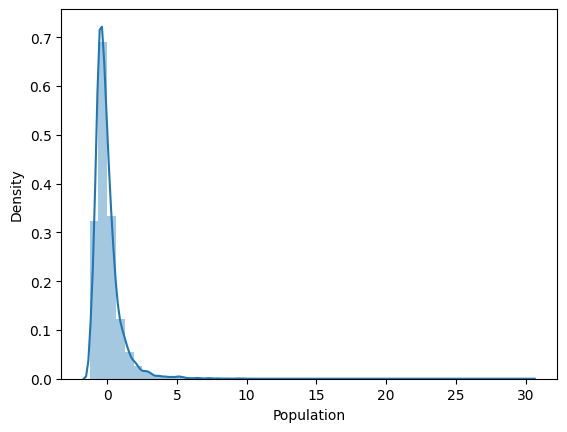

In [ ]:
sns.distplot(scaled_data['Population'])

In [ ]:
#3. Show before and after statistics (mean and std) for 3 features
feature=['MedInc','HouseAge','AveRooms']
#Before
print("Before Standardization")
print(df[feature].agg(['mean','std']))
print("\n")
#After
print("After Standardization")
print(scaled_data[feature].agg(['mean','std']))

Before Standardization
        MedInc   HouseAge  AveRooms
mean  3.870671  28.639486  5.429000
std   1.899822  12.585558  2.474173


After Standardization
            MedInc      HouseAge      AveRooms
mean  4.406467e-17  1.101617e-17  6.885104e-17
std   1.000000e+00  1.000000e+00  1.000000e+00


In [ ]:
 # 3.4.3 Train-Test Split
df.columns


Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')

In [ ]:
X = df.drop('MedHouseVal',axis=1)
y = df['MedHouseVal']

3.5.1 Linear Regression from Scratch (using NumPy) not perform


In [ ]:
# 3.5.2 Linear Regression using Scikit-learn
import numpy as np
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
print("Trining set size:",X_train.shape)
print("Testing set size:",X_test.shape)

Trining set size: (16512, 8)
Testing set size: (4128, 8)


In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
lin_reg = LinearRegression()
lin_reg.fit(X_train,y_train)


LinearRegression()

In [ ]:
y_pred = lin_reg.predict(X_test)
y_pred

array([0.71912284, 1.76401657, 2.70965883, ..., 4.46877017, 1.18751119,
       2.00940251])

In [ ]:
coefficient = lin_reg.coef_
coefficient

array([ 4.48674910e-01,  9.72425752e-03, -1.23323343e-01,  7.83144907e-01,
       -2.02962058e-06, -3.52631849e-03, -4.19792487e-01, -4.33708065e-01])

3.5.3 Gradient Descent Implementation (Bonus: +10%) not perform


In [ ]:
 # 3.6 Part D: Model Evaluation (25%)
 # 3.6.1 Performance Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [ ]:
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)
rmse = np.sqrt(mse)


In [ ]:
print("Mean_absolute_error",mae)
print("Mean_squared_error",mse)
print("Root_mean_squared_error",rmse)
print("R2_score",r2)

Mean_absolute_error 0.5332001304956553
Mean_squared_error 0.5558915986952444
Root_mean_squared_error 0.7455813830127764
R2_score 0.5757877060324508


In [ ]:
 # 3.6.2 Visualization of Results
 # 1. Actual vs. Predicted Plot: Scatter plot with actual prices on x-axis and predicted
 # prices on y-axis. Include a diagonal line representing perfect predictions.

Text(0.5, 1.0, 'Actual vs. Predicted Prices')

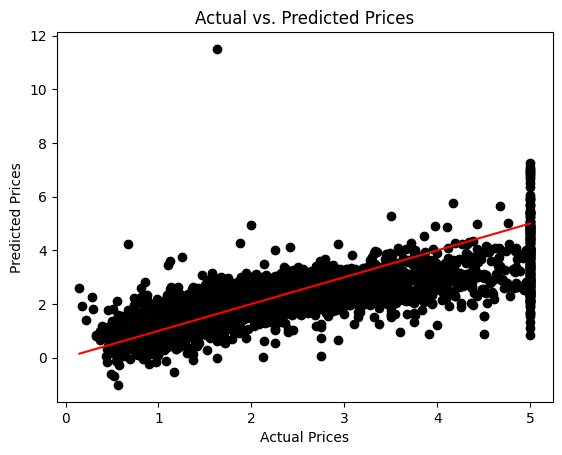

In [ ]:
plt.scatter(y_test,y_pred,color='black')
# plt.plot(y_test,y_test,color='red')
plt.plot([min(y_test),max(y_test)],[min(y_test),max(y_test)],color='red')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs. Predicted Prices")

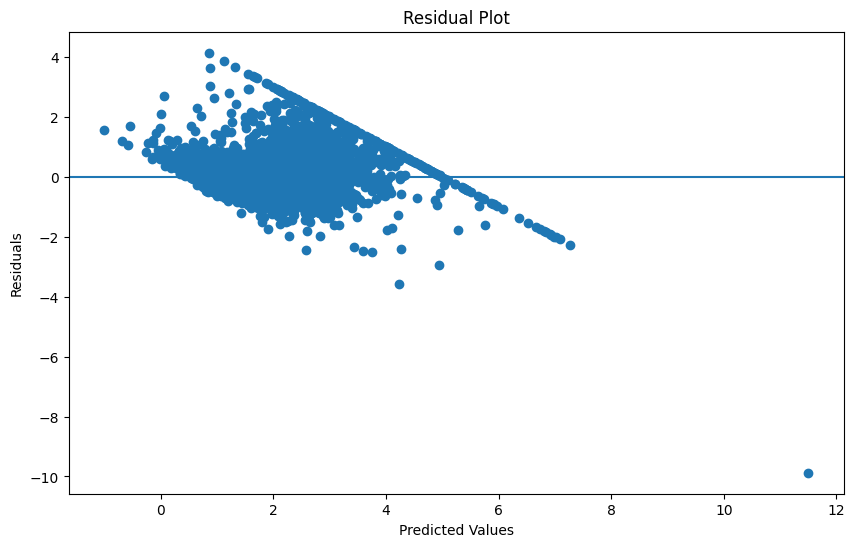

In [ ]:
# 2. Residual Plot: Plot residuals (errors) against predicted values to check for patterns
residual = y_test - y_pred
plt.figure(figsize=(10,6))
plt.scatter(y_pred,residual)
plt.axhline(y=0,) # horizontal line x = 0 draw huncha
plt.title("Residual Plot")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()


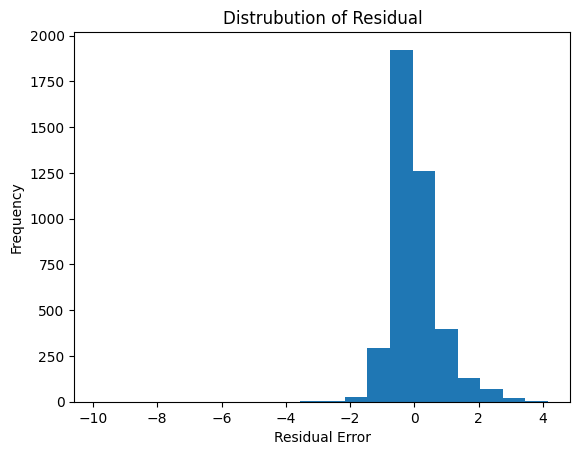

In [ ]:
 # 3. Distribution of Residuals: Histogram showing the distribution of prediction errors
plt.hist(residual,bins=20)
plt.title("Distrubution of Residual")
plt.xlabel("Residual Error")
plt.ylabel("Frequency")
plt.show()


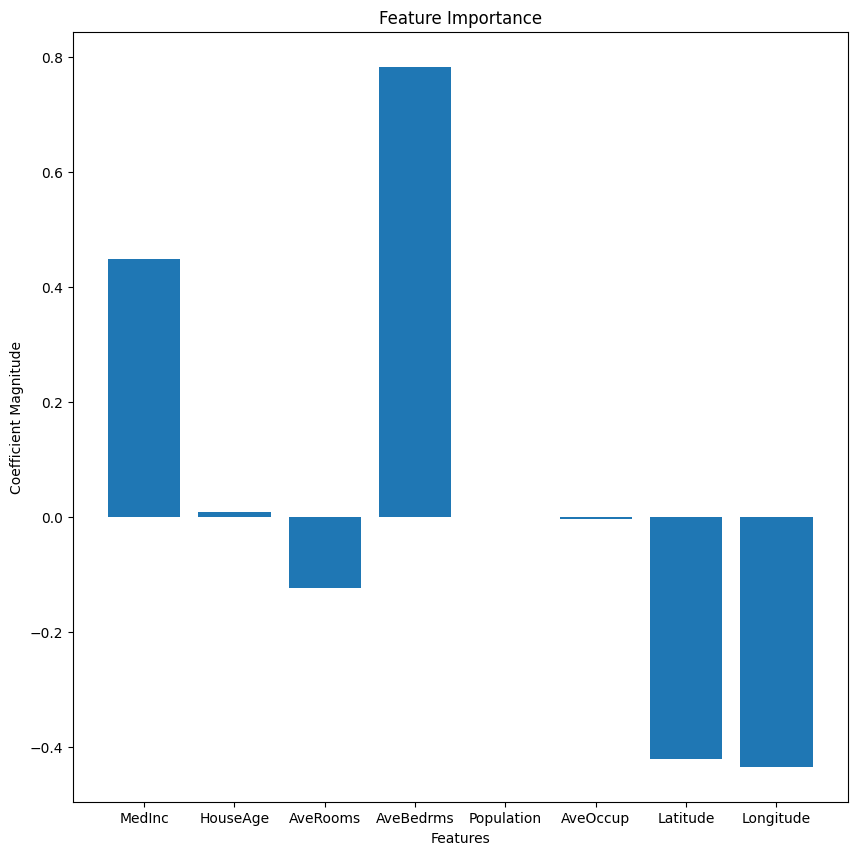

In [ ]:
 # 4. Feature Importance: Bar chart showing the magnitude of coefficients for each feature
feature_names = df.columns[:-1]
plt.figure(figsize=(10,10))
plt.bar(feature_names,coefficient)
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Coefficient Magnitude")
plt.show()



 3.7 Part E: Model Improvement (10%)
 3.7.1 Feature Engineering not perform

In [ ]:
#Why Population is not visible?
#-2.029620580100075e-06 = -0.0000020296..
# It is very close to zero and other are alarge coefficent.Ii means Population has almost no influence in the linear regression model.

In [ ]:
for name,coeff in zip(feature_names,coefficient):
  print(f"{name}:{coeff}")

MedInc:0.44867490966571666
HouseAge:0.009724257517904806
AveRooms:-0.12332334282795815
AveBedrms:0.7831449067929722
Population:-2.029620580100075e-06
AveOccup:-0.003526318487134238
Latitude:-0.4197924865883604
Longitude:-0.433708064963987


In [ ]:
# 1. Identify the 5 houses with largest prediction errors
error = np.abs(y_test - y_pred)


 3.7.2 Regularization
 Implement and compare:
 1. Ridge Regression: J(θ) = MSE +α n
 j=1θ2
 j
 2. Lasso Regression: J(θ) = MSE +α n
 j=1|θj|

In [ ]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import r2_score

In [ ]:
alphas = [0.01,0.1,1,10,100]
ridge_score = [ ]
lasso_score = [ ]

In [ ]:
# Lasoo Regression
for a in alphas:
   lasso =Lasso(alpha = a)
   lasso.fit(X_train,y_train)
   lasso_pred = lasso.predict(X_test)
   lasso_mae = mean_absolute_error(y_test,lasso_pred)
   lasso_mse = mean_squared_error(y_test,lasso_pred)
   lasso_score.append(r2_score(y_test,lasso_pred))

In [ ]:
# Ridge Regression
for a in alphas:
   ridge = Ridge(alpha = a)
   ridge.fit(X_train,y_train)
   ridge_pred = ridge.predict(X_test)
   ridge_mae = mean_absolute_error(y_test,ridge_pred)
   ridge_mse = mean_squared_error(y_test,ridge_pred)
   ridge_score.append(r2_score(y_test, ridge_pred))

In [ ]:
print("Ridge Regression:")
print("MAE:",ridge_mae)
print("MSE:",ridge_mse)
print("\n")
print("Lasso Regression:")
print("MAE:",lasso_mae)
print("MSE:",lasso_mse)

Ridge Regression:
MAE: 0.5337296061093681
MSE: 0.5496801098676332


Lasso Regression:
MAE: 0.9060685490007149
MSE: 1.3106960720039365


In [ ]:
results = pd.DataFrame({
    "Alpha": alphas,
    "Ridge_R2 _Score":  ridge_score,
    "Lasso_R2_Score": lasso_score
})

print(results)

    Alpha  Ridge_R2 _Score  Lasso_R2_Score
0    0.01         0.575788        0.584520
1    0.10         0.575794        0.531817
2    1.00         0.575855        0.284167
3   10.00         0.576437        0.000139
4  100.00         0.580528       -0.000219


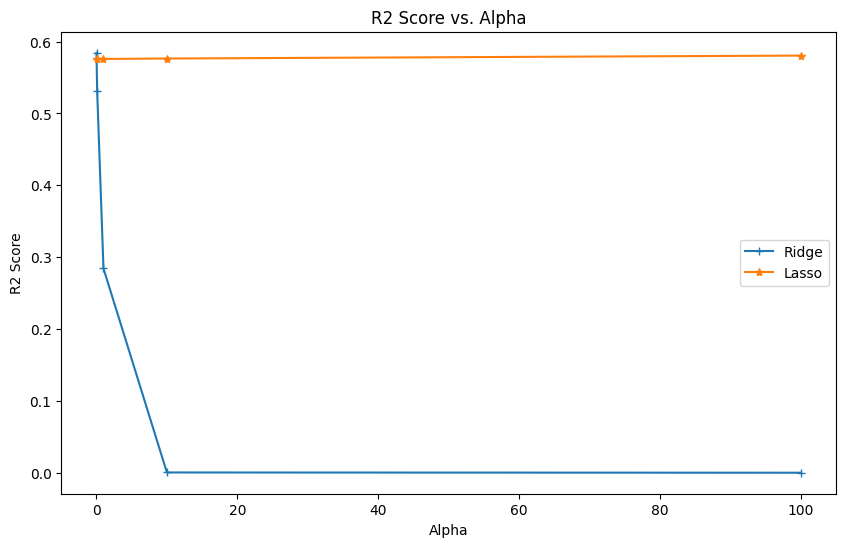

In [ ]:
# Plot R2 score vs. α
plt.figure(figsize=(10,6))
plt.plot(alphas,lasso_score,marker='+',label="Ridge")
plt.plot(alphas,ridge_score,marker='*',label="Lasso")
plt.xlabel("Alpha")
plt.ylabel("R2 Score")
plt.title("R2 Score vs. Alpha")
plt.legend()
plt.show()


 • Report the optimal α value
 • Compare coefficients with standard linear regression not perform below all .